In [1]:
import warnings
import itertools
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
!pip install kagglehub


   ----------------------------------------  0/10 [urllib3]
   ----------------------------------------  0/10 [urllib3]
   -------- -------------------------------  2/10 [pyyaml]
   ------------ ---------------------------  3/10 [protobuf]
   ---------------- -----------------------  4/10 [idna]
   -------------------------------- -------  8/10 [kagglesdk]
   -------------------------------- -------  8/10 [kagglesdk]
   -------------------------------- -------  8/10 [kagglesdk]
   ---------------------------------------- 10/10 [kagglehub]



In [8]:
train = pd.read_csv(r"C:\Users\abidm\Downloads\map-charting-student-math-misunderstandings\train.csv")

In [10]:
test = pd.read_csv(r"C:\Users\abidm\Downloads\map-charting-student-math-misunderstandings\test.csv")

In [12]:
train.head()

,row_id,QuestionId,QuestionText,MC_Answer,StudentExplanation,Category,Misconception
0,0,31772,What fraction of the shape is not shaded? Give...,\( \frac{1}{3} \),0ne third is equal to tree nineth,True_Correct,NaN
1,1,31772,What fraction of the shape is not shaded? Give...,\( \frac{1}{3} \),1 / 3 because 6 over 9 is 2 thirds and 1 third...,True_Correct,NaN
2,2,31772,What fraction of the shape is not shaded? Give...,\( \frac{1}{3} \),"1 3rd is half of 3 6th, so it is simplee to un...",True_Neither,NaN
3,3,31772,What fraction of the shape is not shaded? Give...,\( \frac{1}{3} \),1 goes into everything and 3 goes into nine,True_Neither,NaN
4,4,31772,What fraction of the shape is not shaded? Give...,\( \frac{1}{3} \),1 out of every 3 isn't coloured,True_Correct,NaN


In [13]:
test.head()

,row_id,QuestionId,QuestionText,MC_Answer,StudentExplanation
0,36696,31772,What fraction of the shape is not shaded? Give...,\( \frac{1}{3} \),"I think that 1/3 is the answer, as it's the si..."
1,36697,31772,What fraction of the shape is not shaded? Give...,\( \frac{3}{6} \),i think this answer is because 3 triangles are...
2,36698,32835,Which number is the greatest?,\( 6.2 \),because the 2 makes it higher than the others.


In [14]:
"Train Shapes", train.shape, "\n Test Shapes", test.shape

('Train Shapes', (36696, 7), '\n Test Shapes', (3, 5))

In [15]:
targets = ["Category", "Misconception"]

In [17]:
list(train['Category'].unique())

['True_Correct',
 'True_Neither',
 'True_Misconception',
 'False_Neither',
 'False_Misconception',
 'False_Correct']

In [18]:
train['is_correct'] = train['Category'].str.startswith('True')

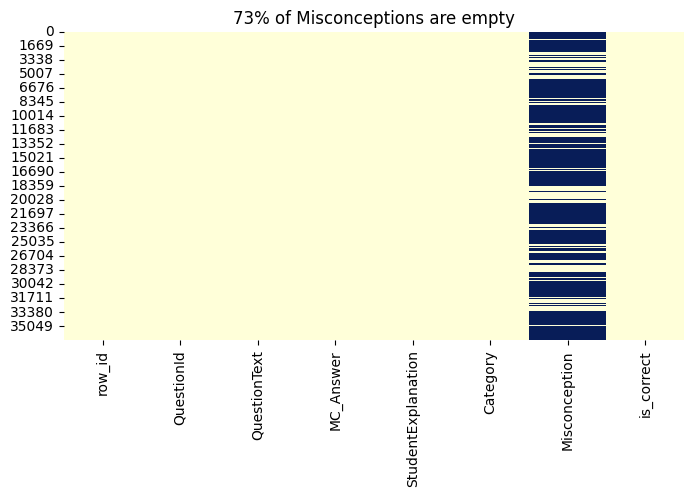

In [19]:
plt.figure(figsize=(8, 4))
sns.heatmap(train.isnull(), cbar=False, cmap="YlGnBu")
plt.title("73% of Misconceptions are empty")
plt.show()
train['Misconception'] = train['Misconception'].fillna('NA')

In [20]:
train['Misconception'].value_counts().to_dict()['NA']/len(train)

0.7313058643993896

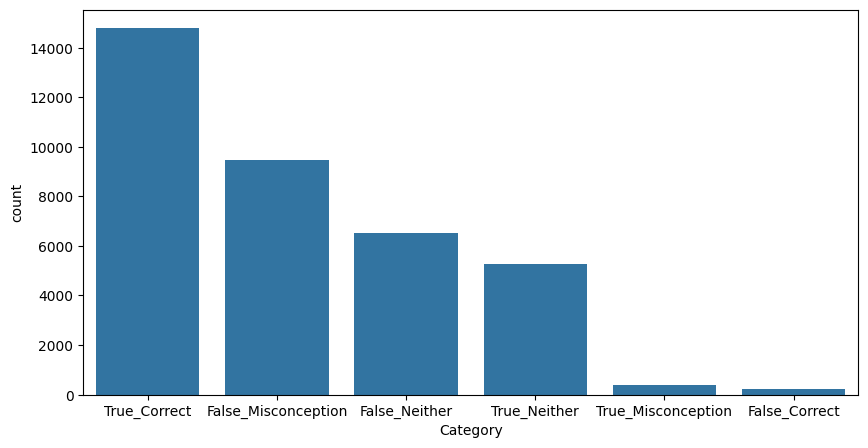

In [21]:
plt.figure(figsize=(10, 5))
sns.countplot(data=train, x='Category', order=train['Category'].value_counts().index)
plt.show()

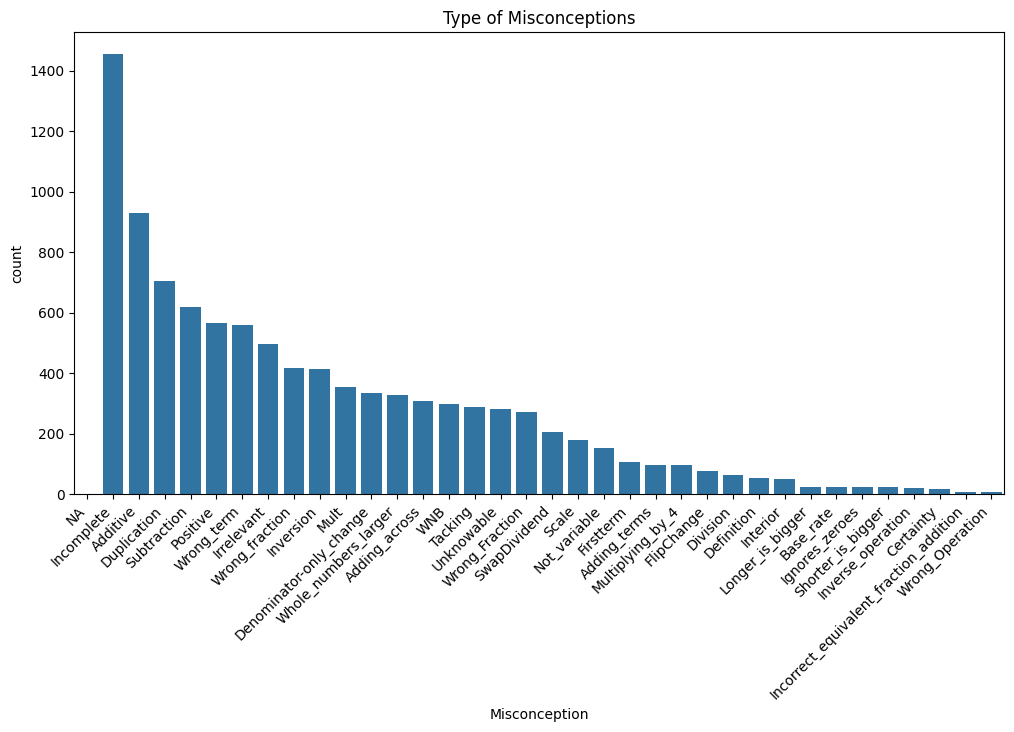

In [23]:
plt.figure(figsize=(12, 6))
sns.countplot(data=train[train['Misconception'] != 'NA'], x='Misconception', order=train['Misconception'].value_counts().index)
plt.xticks(rotation=45, ha='right')
plt.title("Type of Misconceptions")
plt.show()

In [24]:
print(f"Total unique questions: {len(train['QuestionId'].value_counts())}")

Total unique questions: 15


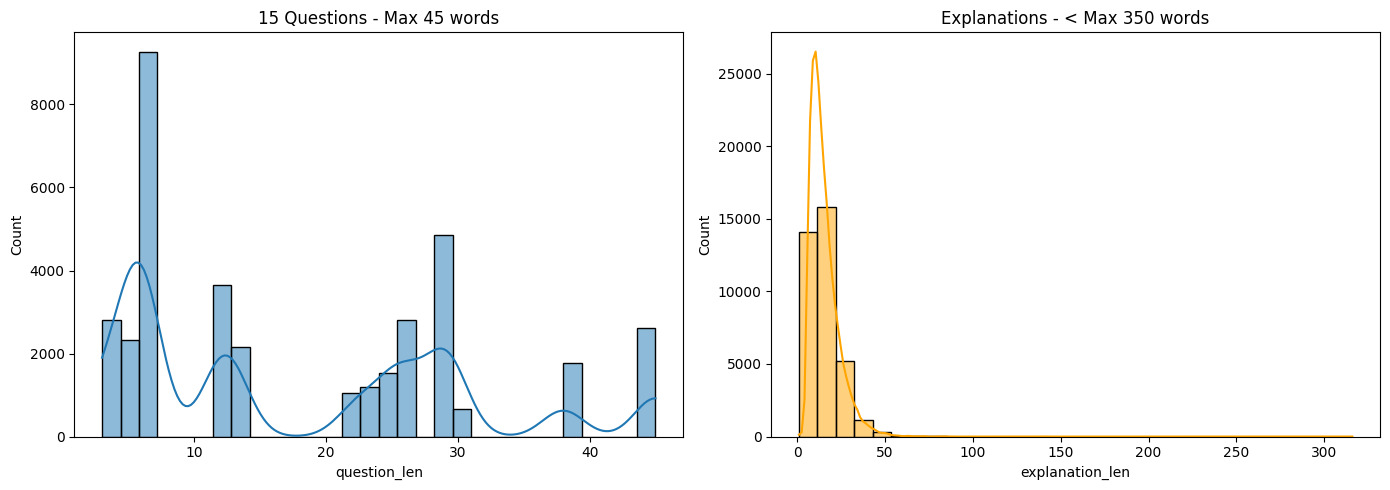

In [25]:
train['question_len'] = train['QuestionText'].apply(lambda x: len(x.split(" ")))
train['explanation_len'] = train['StudentExplanation'].apply(lambda x: len(x.split(" ")))
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train['question_len'], bins=30, ax=axs[0], kde=True)
axs[0].set_title("15 Questions - Max 45 words")
sns.histplot(train['explanation_len'], bins=30, ax=axs[1], kde=True, color="orange")
axs[1].set_title("Explanations - < Max 350 words")
plt.tight_layout()
plt.show()

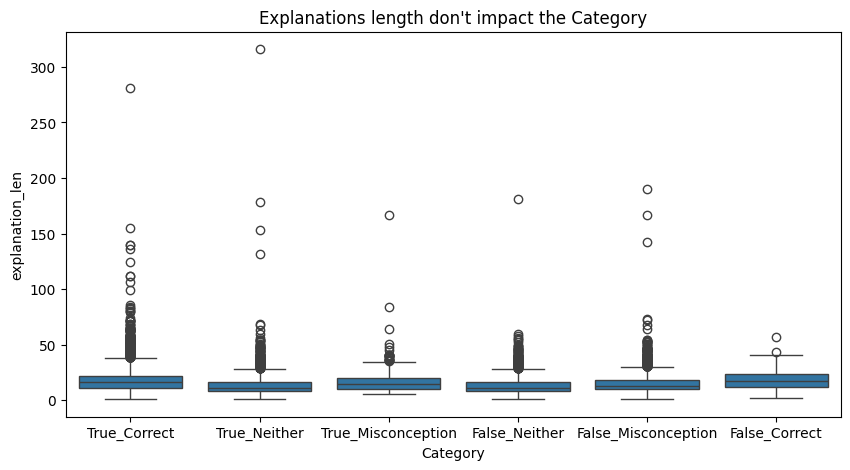

In [26]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=train, x='Category', y='explanation_len')
plt.title("Explanations length don't impact the Category")
plt.show()

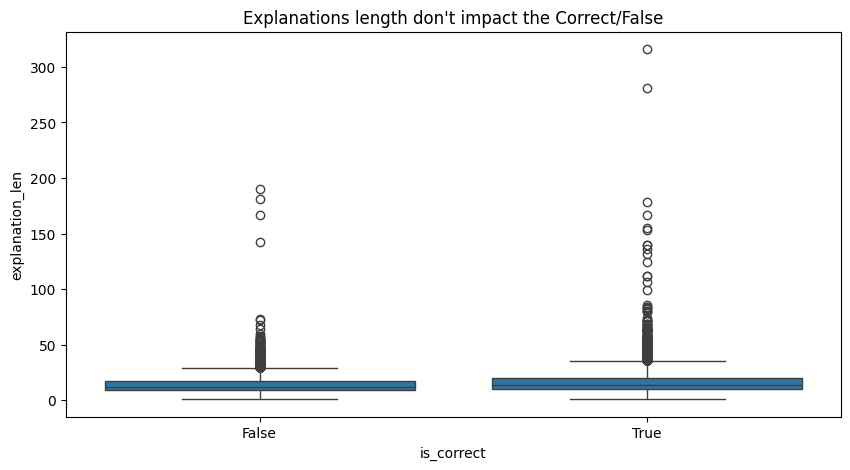

In [27]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=train, x='is_correct', y='explanation_len')
plt.title("Explanations length don't impact the Correct/False")
plt.show()

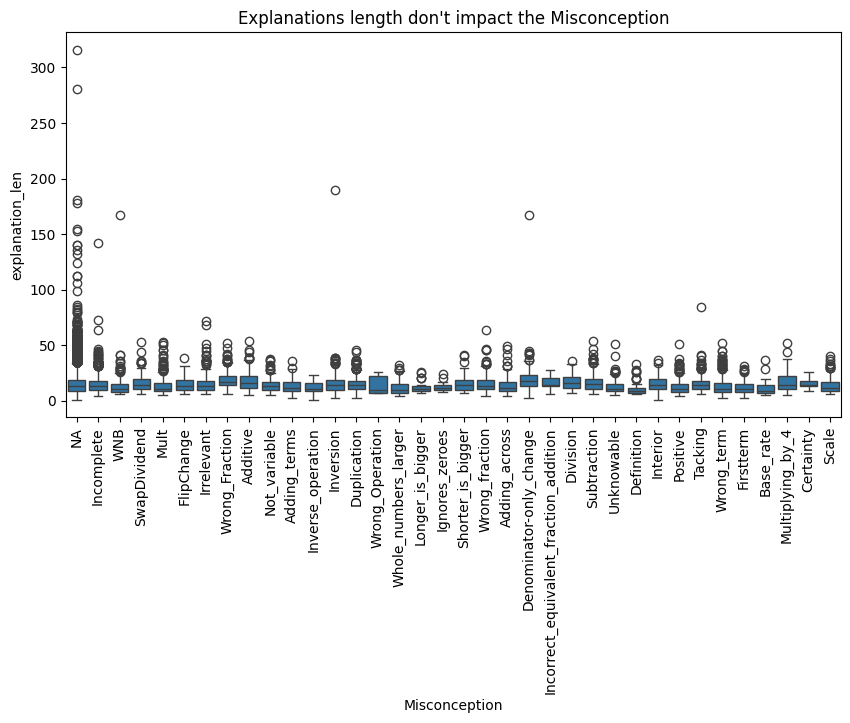

In [28]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=train, x='Misconception', y='explanation_len')
plt.xticks(rotation=90)
plt.title("Explanations length don't impact the Misconception")
plt.show()

In [29]:
categories = list(train['Category'].unique())
categories

['True_Correct',
 'True_Neither',
 'True_Misconception',
 'False_Neither',
 'False_Misconception',
 'False_Correct']

In [33]:
from IPython.display import display, Math, Latex

# GET ANSWER CHOICES
tmp = train.groupby(['QuestionId','MC_Answer']).size().reset_index(name='count')
tmp['rank'] = tmp.groupby('QuestionId')['count'].rank(method='dense', ascending=False).astype(int) - 1
tmp = tmp.drop('count',axis=1)
tmp = tmp.sort_values(['QuestionId','rank'])

# DISPLAY QUESTION AND ANSWER CHOICES
Q = tmp.QuestionId.unique()
for q in Q:
    question = train.loc[train.QuestionId==q].iloc[0].QuestionText
    choices = tmp.loc[tmp.QuestionId==q].MC_Answer.values
    labels="ABCD"
    choice_str = " ".join([f"({labels[i]}) {choice}" for i, choice in enumerate(choices)])
    
    print()
    display(Latex(f"QuestionId {q}: {question}") )
    display(Latex(f"MC Answers: {choice_str}"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

...

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [34]:
def apk(actual, predicted, k=3):
    if len(predicted) > k:
        predicted = predicted[:k]

    score = 0.0
    num_hits = 0.0

    for i, p in enumerate(predicted):
        if p in actual and p not in predicted[:i]:
            num_hits += 1.0
            score += num_hits / (i+1.0)

    if not actual:
        return 0.0

    return score / min(len(actual), k)


def mapk(actual, predicted, k=3):
    return sum([apk(a, p, k) for a, p in zip(actual, predicted)]) / len(actual)

In [35]:
y_true = [['A'], ['C'], ['B']]
y_pred = [['A','B','C'], ['C','A','D'], ['D','B','A']]

In [36]:
score = mapk(y_true, y_pred, k=3)
print("Validation MAP@3:", score)

Validation MAP@3: 0.8333333333333334
